<a href="https://colab.research.google.com/github/rSith/machine-learning-specialization/blob/rSith-dev/ML_Specialization_03_Classification_with_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification
> Classification is a supervised machine learning technique used to predict labels or categories from input data. It assigns each data point to a predefined class based on learned patterns.

##1. Classification problems
- Identifying email as Spam or Not Spam
- Determining if a tumor is malignant or benign

> These are examples of binary classification where there are two possible outcomes.

> Outcomes can be described in pairs of 'positive'/'negative' such as 'yes'/'no', 'true'/'false', or '1'/'0'.

> Plots of classification data sets often use symbols to indicate the outcome of an example. 'X' is used to represent the positive values while 'O' represents negative outcomes.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
X_train2 = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

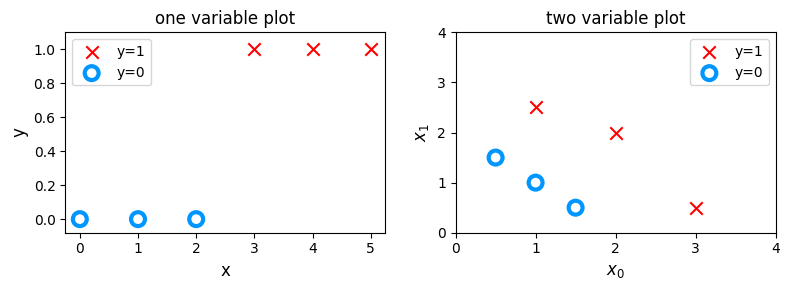

In [5]:
pos = y_train == 1
neg = y_train == 0

fig, ax = plt.subplots(1, 2, figsize=(8, 3))

# plot 1, single variable
ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c='red', label="y=1")
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", facecolors='none', edgecolors='#0096ff', lw=3)

ax[0].set_ylim(-0.08, 1.1)
ax[0].set_ylabel('y', fontsize=12)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_title('one variable plot')
ax[0].legend()

# plot 2, two variables
pos2 = y_train2 == 1
neg2 = y_train2 == 0
ax[1].scatter(X_train2[pos2, 0], X_train2[pos2, 1], marker='x', s=80, c='red', label="y=1")
ax[1].scatter(X_train2[neg2, 0], X_train2[neg2, 1], marker='o', s=100, label="y=0", facecolors='none', edgecolors='#0096ff', lw=3)

ax[1].axis([0, 4, 0, 4])
ax[1].set_ylabel('$x_1$', fontsize=12)
ax[1].set_xlabel('$x_0$', fontsize=12)
ax[1].set_title('two variable plot')
ax[1].legend()
plt.tight_layout()
plt.show()

- In the single variable plot, positive results are shown both a red 'X's and as y=1. Negative results are blue 'O's and are located at y=0.
  - In the case of Linear regression, y would not have been limited to two values but could have been any value.
- In the two- variable plot, the y axis is not avaiable. Positive results are shown as red 'X's, while negative results use the blue 'O' symbol.
  - In the case of linear regression with multiple variables, y would not have been limited to two values and a similar plot would have been three-dimensional.

  

Linear regression is not suitable for classification because:

- Linear regression predicts continuous numbers, not classes.
- Its predictions can be less than 0 or greater than 1.
- Classification usually needs an output between 0 and 1, which can represent a probability.

Therefore, logistic regression is used for classification because it uses the sigmoid function to produce values between 0 and 1.

Sigmoid or Logistic Function
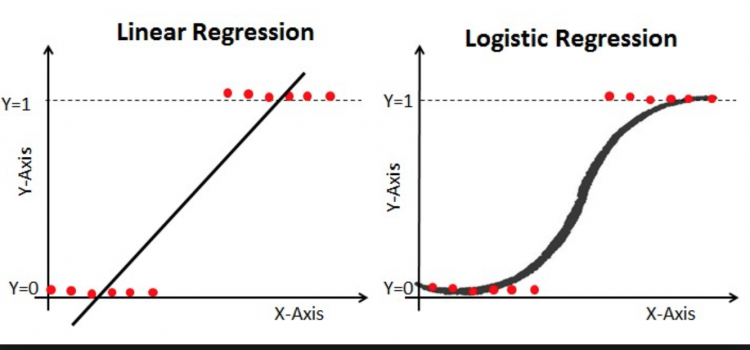

### Formula for Sigmoid function

The formula for a sigmoid function is as follows -  

$g(z) = \frac{1}{1+e^{-z}}\tag{1}$

In the case of logistic regression, z (the input to the sigmoid function), is the output of a linear regression model.
- In the case of a single example, $z$ is scalar.
- in the case of multiple examples, $z$ may be a vector consisting of $m$ values, one for each example.
- The implementation of the sigmoid function should cover both of these potential input formats.

Let's implement this in Python.

NumPy has a function called `exp()`, which offers a convenient way to calculate the exponential ( $e^{z}$) of all elements in the input array (`z`).

In [6]:
def sigmoid(z):

    g = 1/(1+np.exp(-z))

    return g

Let's see what the output of this function is for various value of Z

In [7]:
# Generate an array of evenly spaced values between -10 and 10
z_tmp = np.arange(-10,11)

# Use the function implemented above to get the sigmoid values
y = sigmoid(z_tmp)

# Code for pretty printing the two arrays next to each other
np.set_printoptions(precision=3)
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


The values in the left column are `z`, and the values in the right column are `sigmoid(z)`. As we can see, the input values to the sigmoid range from -10 to 10, and the output values range from 0 to 1.

Now, plot this function using the `matplotlib` library.

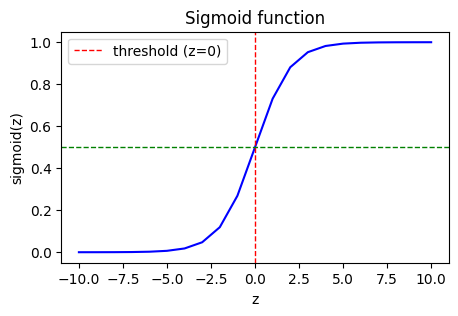

In [8]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')

# Draw vertical and horizontal reference lines to show the threshold at z=0, y=0.5
ax.axvline(0, color='r', linestyle='--', linewidth=1, label="threshold (z=0)")
ax.axhline(0.5, color='g', linestyle='--', linewidth=1)
ax.legend()
plt.show()

> Sigmoid function approaches  `0` as `z` goes to large negative values and approaches `1` as `z` goes to large positive values.

##2. Logistic Regression
> A logistic regression model applies the sigmoid to the familiar linear regression model as shown below:

$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b ) \tag{2} $$

  where

  $g(z) = \frac{1}{1+e^{-z}}\tag{3}$



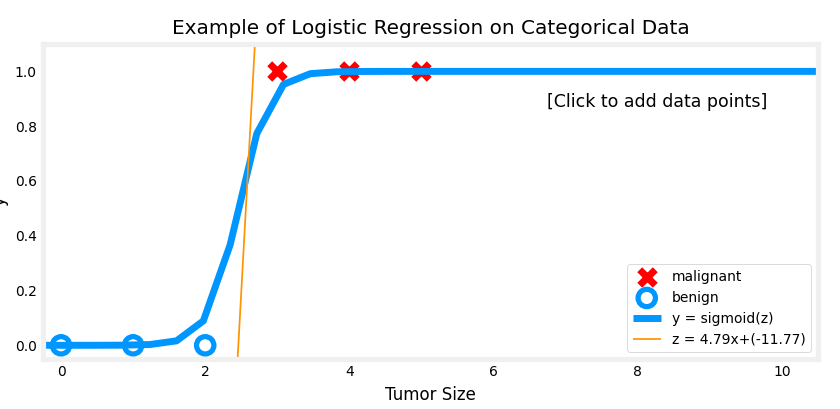

##3. Decision Boundary

> A decision boundary is a line, curve, or surface that separates different classes in a feature space.


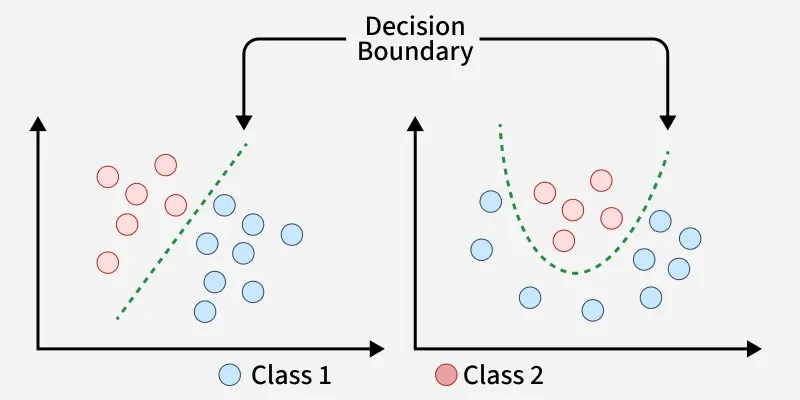

### Dataset
Let's suppose you have following training dataset
- The input variable `X` is a numpy array which has 6 training examples, each with two features
- The output variable `y` is also a numpy array with 6 examples, and `y` is either `0` or `1`

In [9]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1)

The data points with label $y=1$ are shown as red crosses, while the data points with label $y=0$ are shown as blue circles.

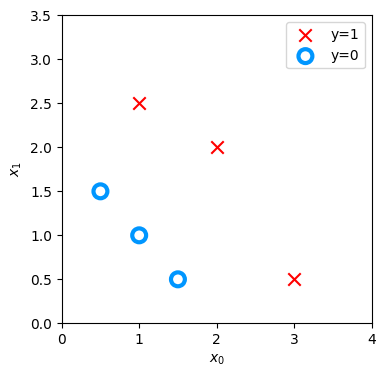

In [10]:
fig,ax = plt.subplots(1,1,figsize=(4,4))

# Find indices of positive and negative classes
pos = y.reshape(-1) == 1
neg = y.reshape(-1) == 0

# Plot data points using standard matplotlib scatter
ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=80, c='red', label="y=1")
ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=100, label="y=0", facecolors='none', edgecolors='#0096ff', lw=3)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
ax.legend()
plt.show()

### Logistic regression model
- Suppose we have to train a logistic regression model on this data whish has the form:

  $f(x) = g(w_0x_0+w_1x_1 + b)$
  
  where $g(z) = \frac{1}{1+e^{-z}}$, which is the sigmoid function

- Let's say that we have trained the model and get the parameters as $b=-3, w_0 = 1, w_1 = 1$. That is, $f(x) = g(x_0 + x_1 - 3)$



### Refresher on logistic regression and decision boundary
- For logistic regression the model is represented as:
 $$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$
where $g(z)$ is known as the sigmodi function and it maps all input values to values between 0 and 1:

  $g(z) = \frac{1}{1+e^{-z}}\tag{2}$
  and $\mathbf{w} \cdot \mathbf{x}$ is the vector dot product:
  
  $$\mathbf{w} \cdot \mathbf{x} = w_0 x_0 + w_1 x_1$$
  
- We interpret the output of the model ($f_{\mathbf{w},b}(x)$) as the probability that $y=1$ given $\mathbf{x}$ and parameterized by $\mathbf{w}$ and $b$.
* Therefore, to get a final prediction ($y=0$ or $y=1$) from the logistic regression model, we can use the following heuristic -

  if $f_{\mathbf{w},b}(x) >= 0.5$, predict $y=1$
  
  if $f_{\mathbf{w},b}(x) < 0.5$, predict $y=0$


Let's plot the sigmoid function to see where $g(z) >= 0.5$

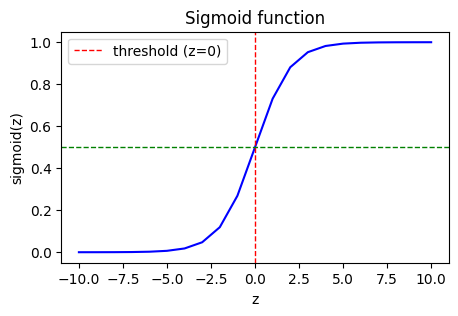

In [12]:
# Plot sigmoid(z) over a range of values from -10 to 10
z = np.arange(-10,11)

fig,ax = plt.subplots(1,1,figsize=(5, 3))
# Plot z vs sigmoid(z)
ax.plot(z, sigmoid(z), c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')

# Draw vertical and horizontal reference lines to show the threshold at z=0, y=0.5
ax.axvline(0, color='r', linestyle='--', linewidth=1, label="threshold (z=0)")
ax.axhline(0.5, color='g', linestyle='--', linewidth=1)
ax.legend()
plt.show()

- We can see, $g(z)>=0.5$ for $z>=0$
- for a logistic regression model, $z = w . x + b$. Therefore,
  - if $w.x+b>=0$, the model predicts $y = 1$
  - if $w.x+b < 0$, the model predicts $y = 0$
   

### PLotting decision boundary
> How the logistic regression model is making predictions?

- Our logistic regression model has the form :  $f(\mathbf{x}) = g(-3 + x_0+x_1)$

- we can see that this model predicts $y=1$ if $-3 + x_0+x_1 >= 0$

Let's see what this looks like graphically. We'll start by plotting $-3 + x_0+x_1 = 0$, which is equivalent to $x_1 = 3 - x_0$.

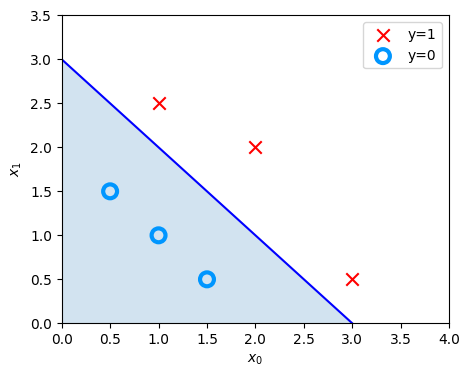

In [15]:
# Choose values between 0 and 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1, 1, figsize=(5,4))
# Plot the decision boundary
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0, x1, alpha=0.2)

# Plot the original data
pos = y.reshape(-1) == 1
neg = y.reshape(-1) == 0
ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=80, c='red', label="y=1")
ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=100, label="y=0", facecolors='none', edgecolors='#0096ff', lw=3)

ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
ax.legend()
plt.show()

* In the plot above, the blue line represents the line $x_0 + x_1 - 3 = 0$ and it should intersect the x1 axis at 3 (if we set $x_1$ = 3, $x_0$ = 0) and the x0 axis at 3 (if we set $x_1$ = 0, $x_0$ = 3).


* The shaded region represents $-3 + x_0+x_1 < 0$. The region above the line is $-3 + x_0+x_1 > 0$.


* Any point in the shaded region (under the line) is classified as $y=0$.  Any point on or above the line is classified as $y=1$. This line is known as the "decision boundary".

By using higher order polynomial terms (eg: $f(x) = g( x_0^2 + x_1 -1)$, we can come up with more complex non-linear boundaries.

## Logistic Loss
### Squared error for logistic regression
For **Linear** Regression we have used the **squared error cost function**:
The equation for the squared error cost with one variable is:
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

where
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$


- The squared error cost for linear regression had the nice property that following the derivative of the cost leads to the minimum.
- The cost function worked well fro linear regression, it is natural to consider it for logistic regression as well.
- However, $f_{wb}(x)$ now has a non-linear component, the sigmoid function:   $f_{w,b}(x^{(i)}) = sigmoid(wx^{(i)} + b )$.  